---
tags: [algorithm, primitive, resource-estimation]
---

# Introduction to the Quantum Fourier Transform (QFT)

The Quantum Fourier Transform (QFT) is the quantum version of the discrete Fourier transform. It is an important subroutine in quantum phase estimation, Shor's algorithm {cite:p}`10.1109/SFCS.1994.365700`, and related algorithms that use phases encoded in quantum amplitudes {cite:p}`10.48550/arXiv.quant-ph/0201067`.

This notebook starts with the classical Fourier transform, explains the QFT circuit, and implements a four-qubit frequency-estimation example. You will draw the circuit, run it on a local Qiskit simulator, estimate the dominant frequency from a histogram, and check the computational complexity scaling.

In [1]:
# Install the latest Qamomile through pip!
# !pip install qamomile

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np

import qamomile.circuit as qmc
from qamomile.circuit.stdlib.qft import qft
from qamomile.qiskit import QiskitTranspiler
from qiskit_aer import AerSimulator

transpiler = QiskitTranspiler()

## Background: Fourier Transform

A Fourier transform rewrites data in terms of frequencies. It tells us which frequencies are present and how strongly. For finite vectors, the version we usually use is the **Discrete Fourier Transform** (DFT).

For a vector $x = (x_0, x_1, \ldots, x_{N-1})$, this notebook uses the following normalized DFT:

$$
y_k = \frac{1}{\sqrt{N}}\sum_{j=0}^{N-1} x_j e^{2\pi i jk / N},
\qquad k = 0, 1, \ldots, N-1.
$$

The output index $k$ labels a frequency component. The angular frequency corresponding to this index is $2\pi k/N$, and the phase factor $e^{2\pi i jk / N}$ makes each input position contribute with a different phase.

## Algorithm

QFT applies the same transform as DFT to the amplitudes of a quantum state. If $N = 2^n$, its action on the computational basis state $\lvert x\rangle$ corresponding to an integer $x$ is

$$
\mathrm{QFT}_N \lvert x \rangle =
\frac{1}{\sqrt{N}}\sum_{k=0}^{N-1} e^{2\pi i xk/N}\lvert k \rangle.
$$

For a general quantum state $\lvert\psi\rangle = \sum_{j=0}^{N-1} a_j\lvert j\rangle$, QFT returns the state obtained by linearly combining the action on each computational basis state $\lvert j\rangle$.

The key difference from a classical DFT is what we can read out. A classical DFT returns the full output vector. QFT transforms the amplitudes of a quantum state and returns the transformed quantum state. A measurement immediately after QFT returns only samples. Later quantum operations can still use the phase information, as in phase estimation.

The standard QFT circuit uses Hadamard gates, controlled phase rotations, and final swaps. For an $n$-qubit register, the exact circuit uses $O(n^2)$ gates, much fewer than applying a dense $2^n \times 2^n$ matrix directly. It is useful to write the phases as binary fractions:

$$
[0.x_jx_{j+1}\ldots x_n] =
\frac{x_j}{2}
+ \frac{x_{j+1}}{2^2}
+ \cdots
+ \frac{x_n}{2^{n-j+1}}
=
\sum_{m=j}^{n} \frac{x_m}{2^{m-j+1}}.
$$

### Step 1: Select one target qubit

Work across the register one target qubit at a time. On the last qubit, a Hadamard gate creates the first factor in the QFT output:

If $x_n=0$, then $H\lvert0\rangle = (\lvert0\rangle + \lvert1\rangle)/\sqrt{2}$. If $x_n=1$, then $H\lvert1\rangle = (\lvert0\rangle - \lvert1\rangle)/\sqrt{2}$, which can be written in the same form using $e^{2\pi i[0.1]} = e^{\pi i} = -1$.

$$
\lvert x_n\rangle
\xrightarrow{H}
\frac{1}{\sqrt{2}}
\left(\lvert 0\rangle + e^{2\pi i[0.x_n]}\lvert 1\rangle\right).
$$

### Step 2: Add controlled phase rotations

Controlled phase rotations from the remaining qubits complete the binary fraction. For a target qubit $x_j$, the Hadamard gate and controlled rotations produce

$$
\lvert x_j\rangle
\longmapsto
\frac{1}{\sqrt{2}}
\left(\lvert 0\rangle + e^{2\pi i[0.x_jx_{j+1}\ldots x_n]}\lvert 1\rangle\right).
$$

These phase rotations are commonly written as $R_k$:

$$
R_k =
\begin{pmatrix}
1 & 0 \\
0 & e^{2\pi i / 2^k}
\end{pmatrix}.
$$

A controlled-$R_k$ applies this rotation to the target only when the control qubit is $\lvert 1\rangle$. If the control and target positions are distance $d$ apart, the QFT circuit uses controlled-$R_{d+1}$. Its rotation angle is

$$
\theta = \frac{2\pi}{2^{d+1}} = \frac{\pi}{2^d}.
$$

### Step 3: Repeat across the register

Repeating this pattern gives the following product form of QFT:

$$
\mathrm{QFT}\lvert x_1x_2\ldots x_n\rangle =
\frac{1}{\sqrt{2^n}}
\bigotimes_{j=n}^{1}
\left(\lvert 0\rangle + e^{2\pi i[0.x_jx_{j+1}\ldots x_n]}\lvert 1\rangle\right).
$$

For the four-qubit case, this is

$$
\mathrm{QFT}\lvert x_1x_2x_3x_4\rangle =
\frac{1}{\sqrt{16}}
\left(\lvert 0\rangle + e^{2\pi i[0.x_4]}\lvert 1\rangle\right)
\otimes
\left(\lvert 0\rangle + e^{2\pi i[0.x_3x_4]}\lvert 1\rangle\right)
\otimes
\left(\lvert 0\rangle + e^{2\pi i[0.x_2x_3x_4]}\lvert 1\rangle\right)
\otimes
\left(\lvert 0\rangle + e^{2\pi i[0.x_1x_2x_3x_4]}\lvert 1\rangle\right).
$$

### Step 4: Reverse the output order

The standard QFT circuit naturally puts the output qubits in reverse order. A final layer of swaps restores the register order. Some algorithms omit these swaps and track the reversed order in classical code.

```{figure} assets/qft_circuit.png
:alt: Standard QFT circuit
:width: 720px

QFT quantum circuit for $n=4$.
```

## Implementation: `qft` function

The `qamomile.circuit.stdlib.qft.qft` function applies the full circuit described above: Hadamard gates, controlled phase rotations, and final swaps.

### Problem Example

We use $N=16$ samples, so four qubits are enough. In this example, we prepare a quantum state whose amplitude for the computational basis state $\lvert j\rangle$ is $s_j$. Here, $n=4$, $N=16$, and $\omega = e^{2\pi i/16}$.

$$
\lvert \psi_f\rangle =
\sum_{j=0}^{N-1} s_j \lvert j\rangle,
\qquad
s_j = \frac{1}{\sqrt{N}} e^{-2\pi i f j/N}
= \frac{1}{\sqrt{N}}\omega^{-fj},
\qquad f=5,\quad j=0,1,\ldots,N-1.
$$

In other words, the values of $e^{-2\pi i f j/N}$ are placed in the amplitudes of $\lvert \psi_f\rangle$, with the normalization factor $1/\sqrt{N}$. Applying QFT sums the contributions from each computational basis state $\lvert j\rangle$, leaving only the frequency index $f$.

$$
\mathrm{QFT}_{n=4}\lvert \psi_f \rangle =
\frac{1}{16}\sum_{j=0}^{15}\sum_{k=0}^{15}\omega^{j(k-f)}\lvert k\rangle
= \lvert f\rangle.
$$

Therefore, when $f=5$, the output should be concentrated at frequency index $k=5$.

In [3]:
num_qubits = 4
dimension = 2**num_qubits
frequency = 5
positions = np.arange(dimension)

signal = np.exp(-2j * np.pi * frequency * positions / dimension) / np.sqrt(dimension)
spectrum = np.fft.ifft(signal, norm="ortho")
expected_spectrum = np.zeros(dimension, dtype=complex)
expected_spectrum[frequency] = 1.0

print(np.round(np.abs(spectrum), 3))
assert np.allclose(spectrum, expected_spectrum)

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### Quantum Kernel with `qft`

Qamomile provides QFT through the standard-library function `qamomile.circuit.stdlib.qft.qft`. It accepts a `Vector[Qubit]`, applies QFT to the whole register, and returns the transformed vector.

The state preparation below creates the phase pattern directly in the amplitudes. We treat `q[0]` as the least significant bit of the sample index $j$, so the phase added to each qubit doubles from left to right.

In [4]:
@qmc.qkernel
def qft_frequency_estimator() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(num_qubits, name="q")

    # Start from a uniform superposition over all sample indices.
    q = qmc.h(q)

    # Encode the phase pattern exp(-2 pi i f j / N) into the amplitudes.
    q[0] = qmc.p(q[0], -2 * math.pi * frequency / dimension)
    q[1] = qmc.p(q[1], -2 * math.pi * frequency * 2 / dimension)
    q[2] = qmc.p(q[2], -2 * math.pi * frequency * 4 / dimension)
    q[3] = qmc.p(q[3], -2 * math.pi * frequency * 8 / dimension)

    # Apply QFT and measure the frequency index.
    q = qft(q)
    return qmc.measure(q)

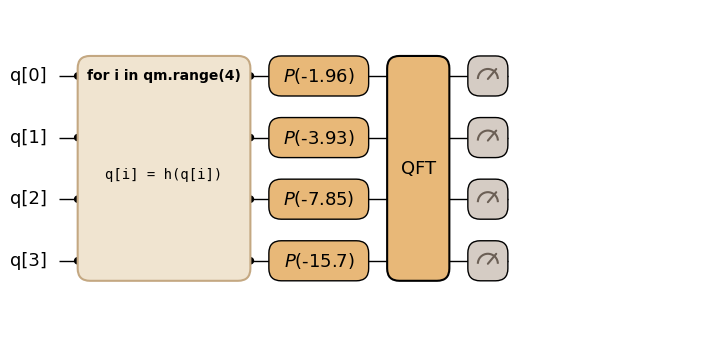

In [5]:
qft_frequency_estimator.draw()

`draw()` shows QFT as one operation. To see the Qiskit circuit after transpilation, convert the qkernel with `to_circuit`.

In [6]:
qiskit_circuit = transpiler.to_circuit(qft_frequency_estimator)
print(qiskit_circuit.draw())

     ┌───┐┌──────────┐┌──────┐┌─┐         
q_0: ┤ H ├┤ P(-5π/8) ├┤0     ├┤M├─────────
     ├───┤├──────────┤│      │└╥┘┌─┐      
q_1: ┤ H ├┤ P(-5π/4) ├┤1     ├─╫─┤M├──────
     ├───┤├──────────┤│  Qft │ ║ └╥┘┌─┐   
q_2: ┤ H ├┤ P(-5π/2) ├┤2     ├─╫──╫─┤M├───
     ├───┤└┬────────┬┘│      │ ║  ║ └╥┘┌─┐
q_3: ┤ H ├─┤ P(-5π) ├─┤3     ├─╫──╫──╫─┤M├
     └───┘ └────────┘ └──────┘ ║  ║  ║ └╥┘
c: 4/══════════════════════════╩══╩══╩══╩═
                               0  1  2  3 


### Execution Result

Now run the qkernel locally and plot a histogram of the measured frequency indices. The conversion below treats `q[0]` as the least significant bit, matching the state preparation above.

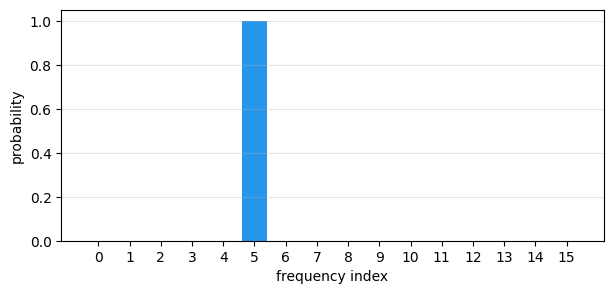

estimated frequency: 5


In [7]:
backend = AerSimulator(seed_simulator=1234, max_parallel_threads=1)
shots = 512
executable = transpiler.transpile(qft_frequency_estimator)
result = executable.sample(transpiler.executor(backend), shots=shots).result()

probabilities = np.zeros(dimension)
for outcome, count in result.results:
    frequency_index = sum(bit << idx for idx, bit in enumerate(outcome))
    probabilities[frequency_index] = count / shots

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(dimension), probabilities, color="#2696EB")
ax.set_xlabel("frequency index")
ax.set_ylabel("probability")
ax.set_xticks(range(dimension))
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.show()

estimated_frequency = int(np.argmax(probabilities))
print(f"estimated frequency: {estimated_frequency}")

assert result.shots == shots
assert sum(count for _, count in result.results) == shots
assert estimated_frequency == frequency
assert probabilities[frequency] > 0.95
assert all(
    isinstance(outcome, tuple) and len(outcome) == num_qubits
    for outcome, _ in result.results
)

## Resource Estimation

The exact QFT circuit uses:

- $n$ Hadamard gates
- $\frac{n(n - 1)}{2}$ controlled phase rotations
- $\left\lfloor n / 2 \right\rfloor$ swaps

Therefore the total gate count is $n + \frac{n(n - 1)}{2} + \left\lfloor n / 2 \right\rfloor$, so it scales as $O(n^2)$.

Now let's use Qamomile's resource estimation feature to check the gate count of the QFT circuit.

In [8]:
# Build a qkernel that applies only QFT to an n-qubit register.
def make_qft_resource_kernel(n: int) -> qmc.QKernel:
    @qmc.qkernel
    def qft_resource_kernel() -> qmc.Vector[qmc.Qubit]:
        q = qmc.qubit_array(n, name="q")
        q = qft(q)
        return q

    return qft_resource_kernel

In [9]:
estimate_4 = make_qft_resource_kernel(4).estimate_resources().simplify()
print("qubits:", estimate_4.qubits)
print("total gates:", estimate_4.gates.total)
print("single-qubit gates:", estimate_4.gates.single_qubit)
print("two-qubit gates:", estimate_4.gates.two_qubit)
print("rotation gates:", estimate_4.gates.rotation_gates)
print("Clifford gates:", estimate_4.gates.clifford_gates)

assert estimate_4.qubits == 4
assert estimate_4.gates.total == 12
assert estimate_4.gates.single_qubit == 4
assert estimate_4.gates.two_qubit == 8
assert estimate_4.gates.rotation_gates == 6
assert estimate_4.gates.clifford_gates == 6

qubits: 4
total gates: 12
single-qubit gates: 4
two-qubit gates: 8
rotation gates: 6
Clifford gates: 6


A direct classical DFT on a length-$N$ vector uses $O(N^2)$ arithmetic operations, and the fast Fourier transform (FFT) uses $O(N\log N)$. If $N = 2^n$, the exact QFT circuit uses $O(n^2)=O((\log N)^2)$ gates. Compared with the direct classical DFT, this is exponentially smaller in $N$. The caveat is important: measuring the state does not give all $N$ Fourier coefficients. QFT is useful when later quantum steps can use the transformed amplitudes without reading out the whole vector.

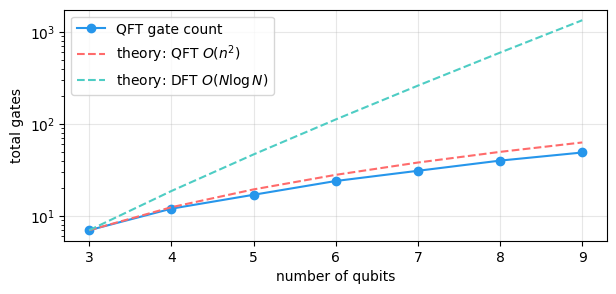

In [10]:
qft_qubit_counts = np.arange(3, 10)
qft_total_gates = []

for n in qft_qubit_counts:
    estimate_n = make_qft_resource_kernel(int(n)).estimate_resources().simplify()
    qft_total_gates.append(int(estimate_n.gates.total))

quadratic_reference = qft_qubit_counts**2
quadratic_reference = quadratic_reference / quadratic_reference[0] * qft_total_gates[0]

dimension_counts = 2**qft_qubit_counts
nlogn_reference = dimension_counts * qft_qubit_counts
nlogn_reference = nlogn_reference / nlogn_reference[0] * qft_total_gates[0]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(
    qft_qubit_counts,
    qft_total_gates,
    marker="o",
    color="#2696EB",
    label="QFT gate count",
)
ax.plot(
    qft_qubit_counts,
    quadratic_reference,
    linestyle="--",
    color="#FF6B6B",
    label=r"theory: QFT $O(n^2)$",
)
ax.plot(
    qft_qubit_counts,
    nlogn_reference,
    linestyle="--",
    color="#4ECDC4",
    label=r"theory: DFT $O(N\log N)$",
)
ax.set_xlabel("number of qubits")
ax.set_ylabel("total gates")
ax.set_yscale("log")
ax.set_xticks(qft_qubit_counts)
ax.grid(alpha=0.3)
ax.legend()
plt.show()

expected_total_gates = [
    n + n * (n - 1) // 2 + n // 2 for n in qft_qubit_counts
]
assert qft_total_gates == expected_total_gates
assert len(quadratic_reference) == len(qft_total_gates)
assert len(nlogn_reference) == len(qft_total_gates)

## Summary

In this notebook, we introduced QFT from the classical DFT, implemented a four-qubit frequency-estimation example, sampled the output, and checked the computational complexity scaling.

- The DFT rewrites a finite vector into frequencies; QFT applies the same transform to quantum amplitudes.
- The four-qubit example prepares a single-frequency phase pattern, applies QFT, and estimates the dominant frequency from the sampled histogram.
- In Qamomile, `qamomile.circuit.stdlib.qft.qft` applies QFT directly to a `Vector[Qubit]`.
- `draw()`, backend execution, and `estimate_resources()` show the circuit, sampled output, and computational complexity scaling of the same QFT structure.